# 01. Build a cluster and read its morphology

**Goal.** Construct an ideal icosahedral gold cluster, then quantify its surface, core and shell structure with `Sapphire.Post_Process.Morphology`.

**You need.** A Sapphire install (`pip install -e .[plot]`). No data download.

Sapphire is a post-processing environment for metallic nanoparticle (MNP) simulations. This series
builds up from a single structure to full molecular-dynamics trajectories; every notebook runs
offline on data bundled with the package and finishes in well under a minute.


## 1.1 Why icosahedra?

Small fcc-metal clusters often prefer non-crystalline **Mackay icosahedra**: 20 (111)-like faces, a
five-fold symmetry axis through every vertex, and concentric shells of `10k² + 2` atoms
(12, 42, 92, 162, 252, …). A 5-shell icosahedron therefore has 1 + 12 + 42 + 92 + 162 + 252 = **561** atoms —
a "magic number" you will meet throughout these tutorials.

Sapphire ships cluster builders in `Sapphire.Utilities.Building`; ASE has equivalents
(`ase.cluster.Icosahedron`) which we also use, so you can cross-check.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.cluster import Icosahedron
from ase.io import write

au = Icosahedron("Au", noshells=6, latticeconstant=4.08)   # 6 shells incl. the centre -> 561 atoms
write("Au561.xyz", au)
print(len(au), "atoms; radius %.2f Å" % np.linalg.norm(au.positions - au.positions.mean(0), axis=1).max())

561 atoms; radius 14.42 Å


## 1.2 Coordination and generalised coordination

The **coordination number** CN counts neighbours inside a cutoff (here 3.2 Å, between the Au first-
and second-neighbour shells at 2.88 and 4.08 Å — Tutorial 02 shows how to choose it from data).
The **generalised coordination number** GCN = Σ_neighbours CN / 12 weights each neighbour by how
well-embedded *it* is; it is the descriptor behind Sapphire's catalysis model (Tutorial 03).

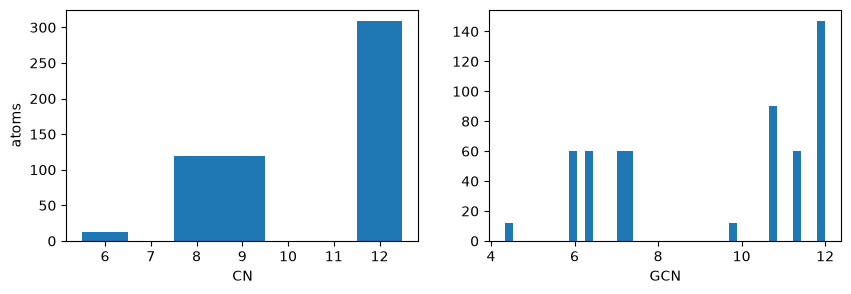

bulk (CN = 12): 309   surface (CN ≤ 10): 252


In [2]:
from Sapphire.Post_Process import Morphology as M

R_CUT = 3.2
adj = M.adjacency(au.positions, R_CUT)
cn, gcn = M.coordination(adj), M.generalised_coordination(adj)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(cn, bins=np.arange(5.5, 13.5)); ax[0].set_xlabel("CN"); ax[0].set_ylabel("atoms")
ax[1].hist(gcn, bins=40); ax[1].set_xlabel("GCN")
plt.show()
print("bulk (CN = 12):", (cn == 12).sum(), "  surface (CN ≤ 10):", (cn <= 10).sum())

A perfect Ih: 309 twelve-fold atoms, 252 surface atoms. The GCN histogram resolves *kinds* of surface
site — vertices, edges and (111) facets have distinct GCN — which CN alone cannot.

## 1.3 Peeling the onion

`Morphology.peel` removes the surface, recomputes, and repeats. For a Mackay icosahedron the shell
populations must come out as 252, 162, 92, 42, 12, 1.

In [3]:
shells = M.peel(au.positions, R_CUT)
print("shell populations:", [len(s) for s in shells])
r = M.radii(au.positions)
for k, s in enumerate(shells):
    print(f"shell {k}: {len(s):4d} atoms, radius {r[s].mean():5.2f} ± {r[s].std():.2f} Å")

shell populations: [252, 162, 92, 42, 12, 1]
shell 0:  252 atoms, radius 12.36 ± 0.71 Å
shell 1:  162 atoms, radius  9.94 ± 0.61 Å
shell 2:   92 atoms, radius  7.53 ± 0.51 Å
shell 3:   42 atoms, radius  5.15 ± 0.39 Å
shell 4:   12 atoms, radius  2.88 ± 0.00 Å
shell 5:    1 atoms, radius  0.00 ± 0.00 Å


## 1.4 Surface area, faceting and volume

Emerald's estimators, now in `Morphology`: surface area as Σ 4πr²(1 − GCN/12) over surface atoms,
faceting ratio (% of atoms on the surface), and a volume built from an inscribed sphere plus one cone
per surface atom. Compare each with the naive sphere of the same outer radius.

In [4]:
d = M.describe(au.positions, R_CUT, r_atom=1.44)
R = r.max() + 1.44
print("faceting ratio      : %.1f %%" % d["faceting_ratio_pct"])
print("surface area        : %.0f Å²   (sphere: %.0f Å²)" % (d["surface_area"], 4*np.pi*R**2))
print("volume              : %.0f Å³   (sphere: %.0f Å³)" % (d["volume"], 4/3*np.pi*R**3))
print("outer shell gap     : %.2f–%.2f Å" % d["shell_thickness"])

faceting ratio      : 44.9 %
surface area        : 2958 Å²   (sphere: 3163 Å²)
volume              : 8239 Å³   (sphere: 16727 Å³)
outer shell gap     : 2.26–2.88 Å


## 1.5 Try it

* Build `Icosahedron("Au", noshells=4)` (147 atoms) and check the shells are 92, 42, 12, 1.
* Build a `Decahedron("Au", p=4, q=3, r=0)` or an `Octahedron` — which has the larger faceting ratio?
* Perturb the positions with `au.rattle(0.15)` and watch the CN histogram smear: this is what a
  finite-temperature frame looks like, and why Tutorial 02 derives the cutoff from the data.

**Next:** *02 — Pair distances and the nearest-neighbour cutoff.*